# Ham or Spam

Bu projede TURKCELL'e gönderilen mesajların spam olup olmadığını bilen bir model geliştireceğiz

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("spam.csv", encoding="iso-8859-1")

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

In [7]:
df.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"], axis=1, inplace=True)

In [8]:
df.columns=["class","text"]

In [9]:
df.head(2)

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [10]:
hepsi=' '.join(df["text"]) # Text sütunundaki bütün satırları birleştirir

In [11]:
hepsi

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat... Ok lar... Joking wif u oni... Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C\'s apply 08452810075over18\'s U dun say so early hor... U c already then say... Nah I don\'t think he goes to usf, he lives around here though FreeMsg Hey there darling it\'s been 3 week\'s now and no word back! I\'d like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv Even my brother is not like to speak with me. They treat me like aids patent. As per your request \'Melle Melle (Oru Minnaminunginte Nurungu Vettam)\' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only. Had your mobile 11 months or more?

In [12]:
import neattext as nt

In [13]:
sent=nt.TextFrame(hepsi)

In [14]:
sent.describe()

Key      Value          
Length  : 451993         
vowels  : 123893         
consonants: 203282         
stopwords: 36082          
punctuations: 22903          
special_char: 23446          
tokens(whitespace): 86335          
tokens(words): 90106          


In [15]:
df.shape

(5572, 2)

In [16]:
sent.length

451993

In [17]:
sent.head(20)

'Go until jurong poin'

In [18]:
sent.tail(23)

'l. Its true to its name'

In [19]:
sent.count_vowels()

{'a': 25248, 'e': 34934, 'i': 22439, 'o': 28962, 'u': 12310}

In [20]:
sent.count_stopwords()

{'go': 262,
 'until': 27,
 'only': 183,
 'in': 855,
 'there': 135,
 'a': 1419,
 'to': 2226,
 'may': 43,
 'say': 80,
 'so': 423,
 'already': 48,
 'then': 205,
 'i': 2208,
 "don't": 134,
 'he': 180,
 'around': 53,
 'here': 79,
 'though': 16,
 "it's": 96,
 'been': 128,
 'now': 247,
 'and': 967,
 'no': 257,
 'some': 118,
 'you': 1917,
 'up': 262,
 'for': 697,
 'it': 465,
 'even': 61,
 'my': 751,
 'is': 862,
 'not': 404,
 'with': 377,
 'they': 124,
 'me': 605,
 'as': 176,
 'per': 56,
 'your': 676,
 'has': 115,
 'all': 259,
 'have': 568,
 'call': 557,
 'had': 100,
 'or': 414,
 'the': 1317,
 'on': 520,
 'be': 375,
 'about': 156,
 'this': 312,
 'enough': 22,
 'six': 4,
 'from': 277,
 'won': 64,
 'our': 142,
 'take': 124,
 'will': 374,
 'at': 398,
 'next': 60,
 'how': 253,
 'his': 57,
 'make': 101,
 'if': 378,
 'its': 207,
 'that': 468,
 'first': 50,
 'when': 282,
 'down': 48,
 'can': 385,
 'just': 363,
 'myself': 9,
 'really': 80,
 'always': 54,
 'did': 115,
 'are': 485,
 'an': 112,
 'over': 5

In [21]:
sent.count_consonants()

{'b': 5310,
 'c': 8876,
 'd': 11275,
 'f': 5745,
 'g': 8284,
 'h': 14204,
 'j': 935,
 'k': 4533,
 'l': 15757,
 'm': 10573,
 'n': 21738,
 'p': 6811,
 'q': 236,
 'r': 17738,
 's': 18898,
 't': 27921,
 'v': 3504,
 'w': 8462,
 'x': 1586,
 'y': 10396,
 'z': 500}

In [22]:
sent.readability()

{'automated readability': 6.9861830850031055,
 'description': '12-13 years (Seventh Grade)'}

In [23]:
import nltk # Natural Language Toolkit

In [24]:
nltk.download("gutenberg")

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\OguzToy\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [25]:
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [26]:
shp=nltk.corpus.gutenberg.raw('shakespeare-macbeth.txt')

In [27]:
shp

"[The Tragedie of Macbeth by William Shakespeare 1603]\n\n\nActus Primus. Scoena Prima.\n\nThunder and Lightning. Enter three Witches.\n\n  1. When shall we three meet againe?\nIn Thunder, Lightning, or in Raine?\n  2. When the Hurley-burley's done,\nWhen the Battaile's lost, and wonne\n\n   3. That will be ere the set of Sunne\n\n   1. Where the place?\n  2. Vpon the Heath\n\n   3. There to meet with Macbeth\n\n   1. I come, Gray-Malkin\n\n   All. Padock calls anon: faire is foule, and foule is faire,\nHouer through the fogge and filthie ayre.\n\nExeunt.\n\n\nScena Secunda.\n\nAlarum within. Enter King Malcome, Donalbaine, Lenox, with\nattendants,\nmeeting a bleeding Captaine.\n\n  King. What bloody man is that? he can report,\nAs seemeth by his plight, of the Reuolt\nThe newest state\n\n   Mal. This is the Serieant,\nWho like a good and hardie Souldier fought\n'Gainst my Captiuitie: Haile braue friend;\nSay to the King, the knowledge of the Broyle,\nAs thou didst leaue it\n\n   Cap. 

In [28]:
sehkp=nt.TextFrame(shp)

In [29]:
sehkp.describe()

Key      Value          
Length  : 100351         
vowels  : 29039          
consonants: 46278          
stopwords: 7895           
punctuations: 4789           
special_char: 4789           
tokens(whitespace): 17741          
tokens(words): 18353          


In [30]:
sehkp.readability()

{'automated readability': 13.40177050724963,
 'description': '18-24 years (College student)'}

In [31]:
import seaborn as sns

In [32]:
df.sample()

,class,text
1874,spam,Would you like to see my XXX pics they are so ...


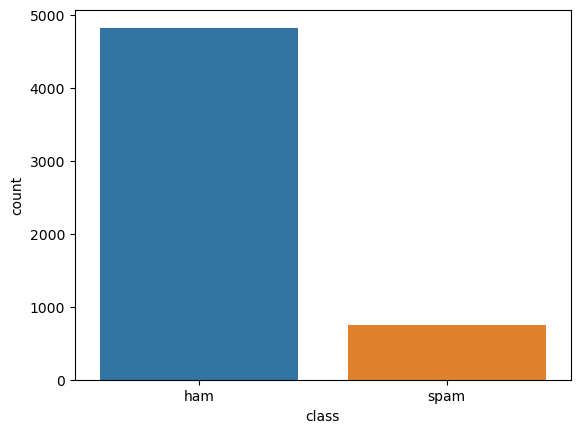

In [33]:
sns.countplot(x=df["class"], hue=df["class"]);

In [34]:
#imbalanced Dataset

In [35]:
df["class"].value_counts()

class
ham     4825
spam     747
Name: count, dtype: int64

In [36]:
#from imblearn.over_sampling import SMOTE
#x,y=SMOTE().fit_resample(x,y)

In [37]:
df["text"]=df["text"].str.lower() # Metindeki tüm kelimeler küçük harfe dönüştürülür
df["text"] = df["text"].str.replace(r'[^\w\s]', '', regex=True)  # metindeki noktalama işaretleri ve özel karakterler (harf, rakam ve boşluk dışındaki) kaldırılır
df["text"] = df["text"].str.replace(r'\d+', '', regex=True)        # metindeki tüm rakamlar  silinir
df["text"] = df["text"].str.replace(r'\n', '', regex=True)         # satır atlama (newline) karakterleri kaldırılır
df["text"] = df["text"].str.replace(r',\r', '', regex=True)        # virgül ve ardından gelen carriage return karakterleri silinir

In [38]:
x=df["text"]
y=df["class"]

In [39]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
from sklearn.pipeline import Pipeline

In [42]:
clf=Pipeline([("tfidf",TfidfVectorizer()),("classifier",RandomForestClassifier())])

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=.2, random_state=42)

In [45]:
clf.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier', RandomForestClassifier())])

In [46]:
pred=clf.predict(x_test)

In [47]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [48]:
accuracy_score(y_test, pred)

0.9721973094170404

In [49]:
confusion_matrix(y_test, pred)

array([[965,   0],
       [ 31, 119]], dtype=int64)

In [50]:
from sklearn.svm import SVC

In [51]:
svm=Pipeline([("tfidf",TfidfVectorizer()),("classifier",RandomForestClassifier())])

In [52]:
svm.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier', RandomForestClassifier())])

In [53]:
pred=svm.predict(x_test)

In [54]:
accuracy_score(y_test, pred)

0.9721973094170404

In [55]:
confusion_matrix(y_test, pred)

array([[965,   0],
       [ 31, 119]], dtype=int64)

<Axes: >

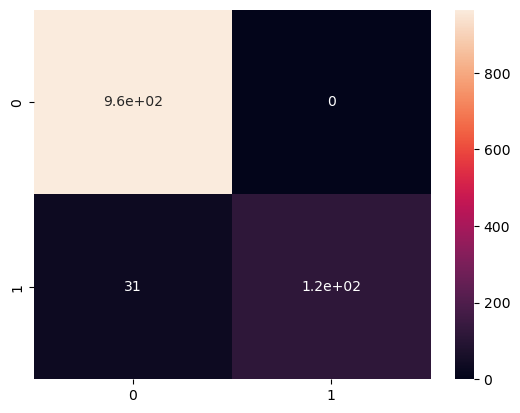

In [56]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True)

In [57]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       965
        spam       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [58]:
test1=["Hello, you are learning Natural Language Processing"]
test2=["Congratulations, you won a lottary ticket. To claim call 1 -800-899-9999"]
test3=["Click here to claim your $1 billion"]

In [59]:
print(clf.predict(test1))

['ham']


In [60]:
print(svm.predict(test1))

['ham']


In [61]:
print(clf.predict(test2))

['spam']


In [62]:
print(svm.predict(test2))

['spam']


In [63]:
print(clf.predict(test3))

['ham']


In [64]:
print(svm.predict(test3))

['ham']


In [65]:
df["text"][2]

'free entry in  a wkly comp to win fa cup final tkts st may  text fa to  to receive entry questionstd txt ratetcs apply overs'

In [66]:
svm.predict([df["text"][2]])

array(['spam'], dtype=object)

In [67]:
ham=df[df["class"]=="ham"]

In [68]:
spam=df[df["class"]=="spam"]

In [69]:
#pip install wordcloud

In [70]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [71]:
def wc(data,color,file):
    plt.figure(figsize=(7,7))
    mask=np.array(Image.open(file))
    wc=WordCloud(background_color=color, stopwords=STOPWORDS,mask=mask)
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis("off")

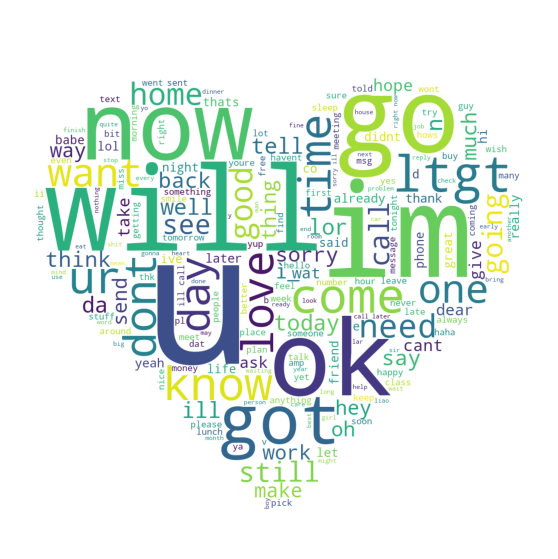

In [72]:
wc(ham["text"], "white", "heart.png")

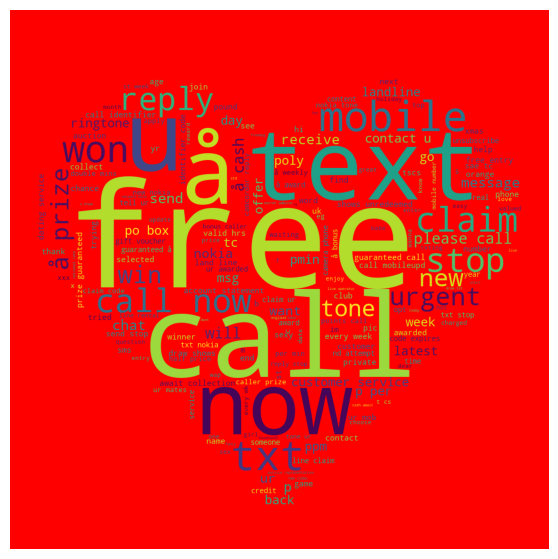

In [73]:
wc(spam["text"], "red", "heart.png")

In [74]:
# Data Augmentation - Var olan datadan yeni datalar oluşturma
# Synthetic data 

In [75]:
ham.shape[0]

4825

In [76]:
spam=spam.sample(ham.shape[0], replace=True)

In [77]:
ham.shape, spam.shape

((4825, 2), (4825, 2))

In [78]:
data = pd.concat([ham,spam], ignore_index=True)

In [79]:
data.shape

(9650, 2)

In [80]:
data.sample(10)

,class,text
7083,spam,hope you enjoyed your new content text stop to...
3675,ham,juz now havent woke up so a bit blur blur can ...
8907,spam,we have new local dates in your area lots of ...
1239,ham,looks like u wil b getting a headstart im leav...
3470,ham,im fine babes aint been up much tho saw scary...
5974,spam,i want some cock my hubbys away i need a real ...
3198,ham,what happen dear tell me
4418,ham,oh you got many responsibilities
6503,spam,u have a secret admirer who is looking make c...
3884,ham,my computer just fried the only essential part...


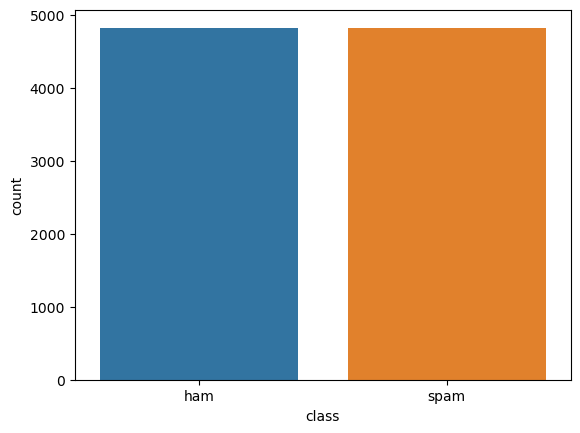

In [81]:
sns.countplot(x=data["class"], hue=data["class"]);

In [82]:
x_train, x_test, y_train, y_test = train_test_split(data["text"],data["class"], test_size=.2, random_state=42)

In [83]:
clf=Pipeline([("tfidf",TfidfVectorizer()),("classifier",RandomForestClassifier())])

In [84]:
clf.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier', RandomForestClassifier())])

In [85]:
pred=clf.predict(x_test)

In [86]:
accuracy_score(y_test, pred)

1.0

In [87]:
confusion_matrix(y_test, pred)

array([[985,   0],
       [  0, 945]], dtype=int64)

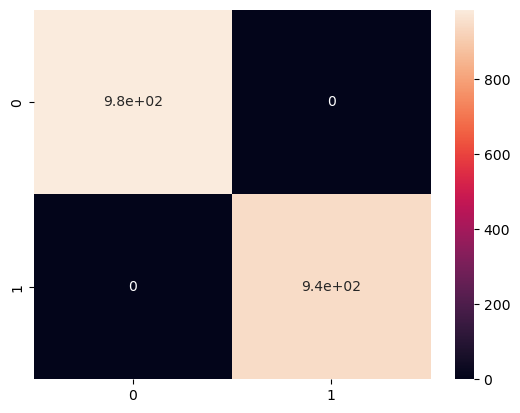

In [88]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True);

In [89]:
# Sentiment Analysis

In [90]:
from textblob import TextBlob

In [91]:
text = "I love Data Science!"

In [92]:
blob=TextBlob(text)

In [93]:
blob.sentiment

Sentiment(polarity=0.625, subjectivity=0.6)

In [94]:
#pip install spacy

In [95]:
#!python -m spacy download en_core_web_md

In [96]:
import spacy

- Tokenization
- Named Entity Recognition
- Topic Modelling
- PoS tagging
- Lemma Stemma

In [98]:
nlp=spacy.load(name="en_core_web_md")

In [99]:
s1='''If the time has come to weigh anchor from life,
A ship bound for the unknown departs this port in silence.
It sails away as if with no passengers aboard;
No hand waves, no kerchief flutters at its departure.

Those left on the pier are sorrowful for this journey,
Their eyes moist, gazing for days at the dark horizon.
Poor hearts! This is not the last ship to depart,
Nor is it the final mourning of a life full of sorrow.'''

In [100]:
print(s1.split())

['If', 'the', 'time', 'has', 'come', 'to', 'weigh', 'anchor', 'from', 'life,', 'A', 'ship', 'bound', 'for', 'the', 'unknown', 'departs', 'this', 'port', 'in', 'silence.', 'It', 'sails', 'away', 'as', 'if', 'with', 'no', 'passengers', 'aboard;', 'No', 'hand', 'waves,', 'no', 'kerchief', 'flutters', 'at', 'its', 'departure.', 'Those', 'left', 'on', 'the', 'pier', 'are', 'sorrowful', 'for', 'this', 'journey,', 'Their', 'eyes', 'moist,', 'gazing', 'for', 'days', 'at', 'the', 'dark', 'horizon.', 'Poor', 'hearts!', 'This', 'is', 'not', 'the', 'last', 'ship', 'to', 'depart,', 'Nor', 'is', 'it', 'the', 'final', 'mourning', 'of', 'a', 'life', 'full', 'of', 'sorrow.']


In [101]:
doc1=nlp(s1)

In [102]:
#for token in doc1:
#    print(token)
[x for x in doc1]

[If,
 the,
 time,
 has,
 come,
 to,
 weigh,
 anchor,
 from,
 life,
 ,,
 ,
 A,
 ship,
 bound,
 for,
 the,
 unknown,
 departs,
 this,
 port,
 in,
 silence,
 .,
 ,
 It,
 sails,
 away,
 as,
 if,
 with,
 no,
 passengers,
 aboard,
 ;,
 ,
 No,
 hand,
 waves,
 ,,
 no,
 kerchief,
 flutters,
 at,
 its,
 departure,
 .,
 
 ,
 Those,
 left,
 on,
 the,
 pier,
 are,
 sorrowful,
 for,
 this,
 journey,
 ,,
 ,
 Their,
 eyes,
 moist,
 ,,
 gazing,
 for,
 days,
 at,
 the,
 dark,
 horizon,
 .,
 ,
 Poor,
 hearts,
 !,
 This,
 is,
 not,
 the,
 last,
 ship,
 to,
 depart,
 ,,
 ,
 Nor,
 is,
 it,
 the,
 final,
 mourning,
 of,
 a,
 life,
 full,
 of,
 sorrow,
 .]

In [103]:
s1=[x for x in doc1]

In [104]:
[x.lemma_ for x in s1]  # ekleri kaldırıp kökleri bulma

['if',
 'the',
 'time',
 'have',
 'come',
 'to',
 'weigh',
 'anchor',
 'from',
 'life',
 ',',
 '\n',
 'a',
 'ship',
 'bind',
 'for',
 'the',
 'unknown',
 'depart',
 'this',
 'port',
 'in',
 'silence',
 '.',
 '\n',
 'it',
 'sail',
 'away',
 'as',
 'if',
 'with',
 'no',
 'passenger',
 'aboard',
 ';',
 '\n',
 'no',
 'hand',
 'wave',
 ',',
 'no',
 'kerchief',
 'flutter',
 'at',
 'its',
 'departure',
 '.',
 '\n\n',
 'those',
 'leave',
 'on',
 'the',
 'pier',
 'be',
 'sorrowful',
 'for',
 'this',
 'journey',
 ',',
 '\n',
 'their',
 'eye',
 'moist',
 ',',
 'gaze',
 'for',
 'day',
 'at',
 'the',
 'dark',
 'horizon',
 '.',
 '\n',
 'poor',
 'heart',
 '!',
 'this',
 'be',
 'not',
 'the',
 'last',
 'ship',
 'to',
 'depart',
 ',',
 '\n',
 'nor',
 'be',
 'it',
 'the',
 'final',
 'mourning',
 'of',
 'a',
 'life',
 'full',
 'of',
 'sorrow',
 '.']

In [105]:
doc=nlp("Apple is looking at buying U.K startup for $1 billion")

In [106]:
for token in doc:
    print(token.text, token.lemma_, token.pos_, token.tag_)

Apple Apple PROPN NNP
is be AUX VBZ
looking look VERB VBG
at at ADP IN
buying buy VERB VBG
U.K U.K PROPN NNP
startup startup NOUN NN
for for ADP IN
$ $ SYM $
1 1 NUM CD
billion billion NUM CD


In [107]:
from spacy import displacy

In [108]:
displacy.render(doc,style="dep")

In [109]:
# Named Entity Recognition - NER

In [110]:
text="When Tom started working on self driving card at Google in 2028 in New York, few people believed him. But now he is working at CERN and NASA"

In [111]:
doc=nlp(text)

In [112]:
displacy.render(doc, style="ent")